# Diffusion & Flow Exercise
Run cells in order. 
Plots will be shown inline.

## 1 Diffusion is not like a flow with a fixed rate

In diffusion, molecules move randomly due to thermal motion.
There is no fixed “flow rate” like in a pipe.
The longer the distance a molecule has to travel, the longer it will typically take to get there.
So, “all molecules will eventually diffuse anyway” is true — but the time it takes grows with the square of the distance. That’s why diffusion is only fast over short distances.

The **characteristic distance** is essentially the **typical distance over which something diffuses** — the distance you care about for your problem. It’s not “every molecule travels exactly this distance”. It’s the **scale at which diffusion matters**.
Think of it as the **length scale of your system**.

1. **Inside a cell**
   * A cell might be 10 µm across.
   * If oxygen has to get from the cell membrane to the center, the **characteristic distance** is ~10 µm.
2. **Tissue**
   * A layer of tissue might be 1 mm thick.
   * Oxygen has to diffuse from the nearest blood vessel to the middle of the tissue.
   * Then the characteristic distance is ~0.5 mm (half the thickness, because on average molecules start at the edge and diffuse to the center).
3. **Diffusion in air**
   * If you spray perfume in a room, the characteristic distance could be meters — the scale over which you’re asking “how long does it take for molecules to spread?”

## What $x$ really means
$x$ is a **characteristic distance over which you care about diffusion**. For example: 
If you have a cell 10 µm thick, $x \sim 10, \mu m$ is the distance oxygen needs to travel from the capillary to the center of the cell. 
9 If you have a 1 mm tissue, $x \sim 1, mm$ is the distance oxygen needs to reach the middle.
The diffusion timescale formula:
$$
t \sim \frac{x^2}{2D}
$$
So diffusion works for **local transport**, but it cannot efficiently supply large distances quickly. Intuitively, you can think like this:
For **tiny distances (µm)** diffusion is extremely fast — basically instantaneous for cells.
For **millimeter distances** diffusion is slow — which is why tissues thicker than ~0.1–0.2 mm need **blood vessels** to bring oxygen in.

### **Exercise: Diffusion Timescale**
Compute the diffusion timescale across different tissue thicknesses, with lengths of 1 µm and 1 mm and $D = 1.8\cdot 10^{-3} mm^2/s$ as the diffusion coefficient for $O_2$.
* What are the timescales for the two different tissue thicknesses, 1 µm and 1 mm?
* Assume that a timescale greater than 2 ms is too large for efficient diffusion of $O_2$. Considering diffusion alone, at what thickness is diffusion no longer viable?

In [ ]:
# %load files/diffusion_time.py
import math
import numpy as np
np.set_printoptions(precision=3, suppress=True)

D = 0.0018  # mm^2/s, same as 1.8e-5 cm^2/s
x1 = 0.001
x2 = 1

# Solution

Hello


## Fick + Convection (analytic steady 1D solution)

If the boundary conditions for Concentration are known (Concentrations limits, i.e. the maximum value C0, at origin x=0.0mm, and minimum value CL , at maximum distance from origin x=0.1mm), the equation for Concentration (C) can be modelled using the following equation:

$$ C(x) = C_0 + (C_L - C_0)\frac{e^{\frac{v x}{D} } - 1}{e^{\frac{v L}{D}} - 1} $$



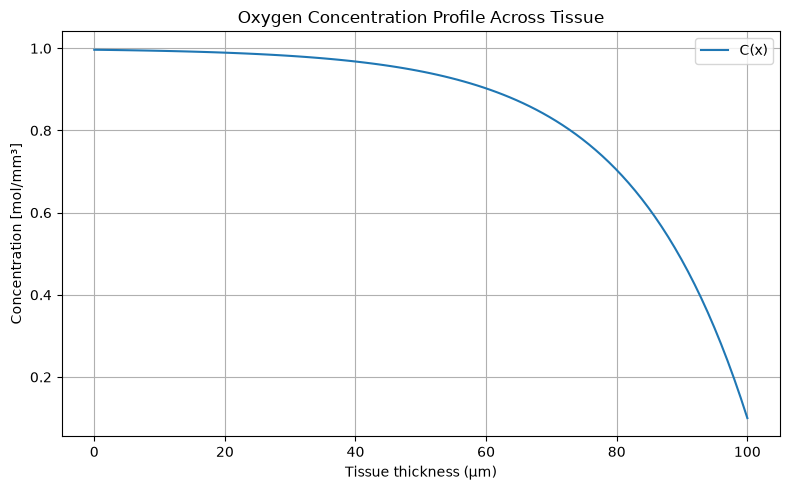

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# Define parameters
C0 = 1.0  # mol/mm^3
CL = 0.1  # mol/mm^3
L_axial = 0.1  # mm
v = 0.1  # mm/s
D = 1.8e-3  # mm^2/s

# Create position array from 0 to L
x = np.linspace(0, L_axial, 100)

# Compute concentration profile using analytical solution
C = C0 + (CL - C0) * np.exp(v * x / D) / np.exp(v * L_axial / D)

# Plot the concentration profile
plt.figure(figsize=(8, 5))
plt.plot(x * 1e3, C, label="C(x)")
plt.xlabel("Tissue thickness (μm)")
plt.ylabel("Concentration [mol/mm³]")
plt.title("Oxygen Concentration Profile Across Tissue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



However, if we do not know the boundary conditions, or if the flow is diffusion dominated, we may use the differential equation $-D \frac{d^2C}{dx^2} + v \frac{dC}{dx} = 0$, which integrates into an exponential decay model, where $\lambda_{eff} = \sqrt{2 D \Delta t}$ and $\Delta t = \frac{L_{axial}}{v}$. 

$$ C(x) = C_0 * e^{\frac{-x}{\lambda_{eff}}} $$


### Flux 
Of course, molecules move both in and out of the liquids, it is a question of how fast it moves from one concentration to another. To consider this movement, we can use the steady 1D convection–diffusion equation to calculate flux:
    
$$ 
J_s = -D \frac{\partial C(x,t)}{\partial x} + J_v C(x,t) 
$$

### Peclet's Number
The Péclet number (Pe) is a dimensionless quantity representing the ratio of transport by convection (advection) to transport by diffusion, and for oxygen transfer from blood to a cell, it can be generally expressed as 
$$Pe = \frac{\text{convective transport​}}{\text{diffusive transport}}= \frac{v * L}{D}$$

Here:
* `v` is the characteristic fluid velocity (e.g., red blood cell velocity or plasma flow velocity)
* `L` is a characteristic length scale (such as the capillary radius or cell size)
* `D` is the diffusion coefficient of oxygen in the surrounding medium (e.g., plasma or tissue)

A high `Pe` value, where convection dominates, means oxygen is quickly transported by the flow, while a low value indicates diffusion is the primary transport mechanism


**Interpretation for Oxygen Transfer**
- Microchannel studies: have shown that for small channel heights and high flow rates, the Péclet number is large, indicating that advection (convection) is the primary mode of oxygen transport. 
- In the microvascular system, the flow of blood and red blood cells moves oxygen towards the tissues. The Péclet number helps determine if the rate of delivery by this flow is sufficient to meet the metabolic demand of the tissue, or if diffusion-limited transport becomes the bottleneck. 


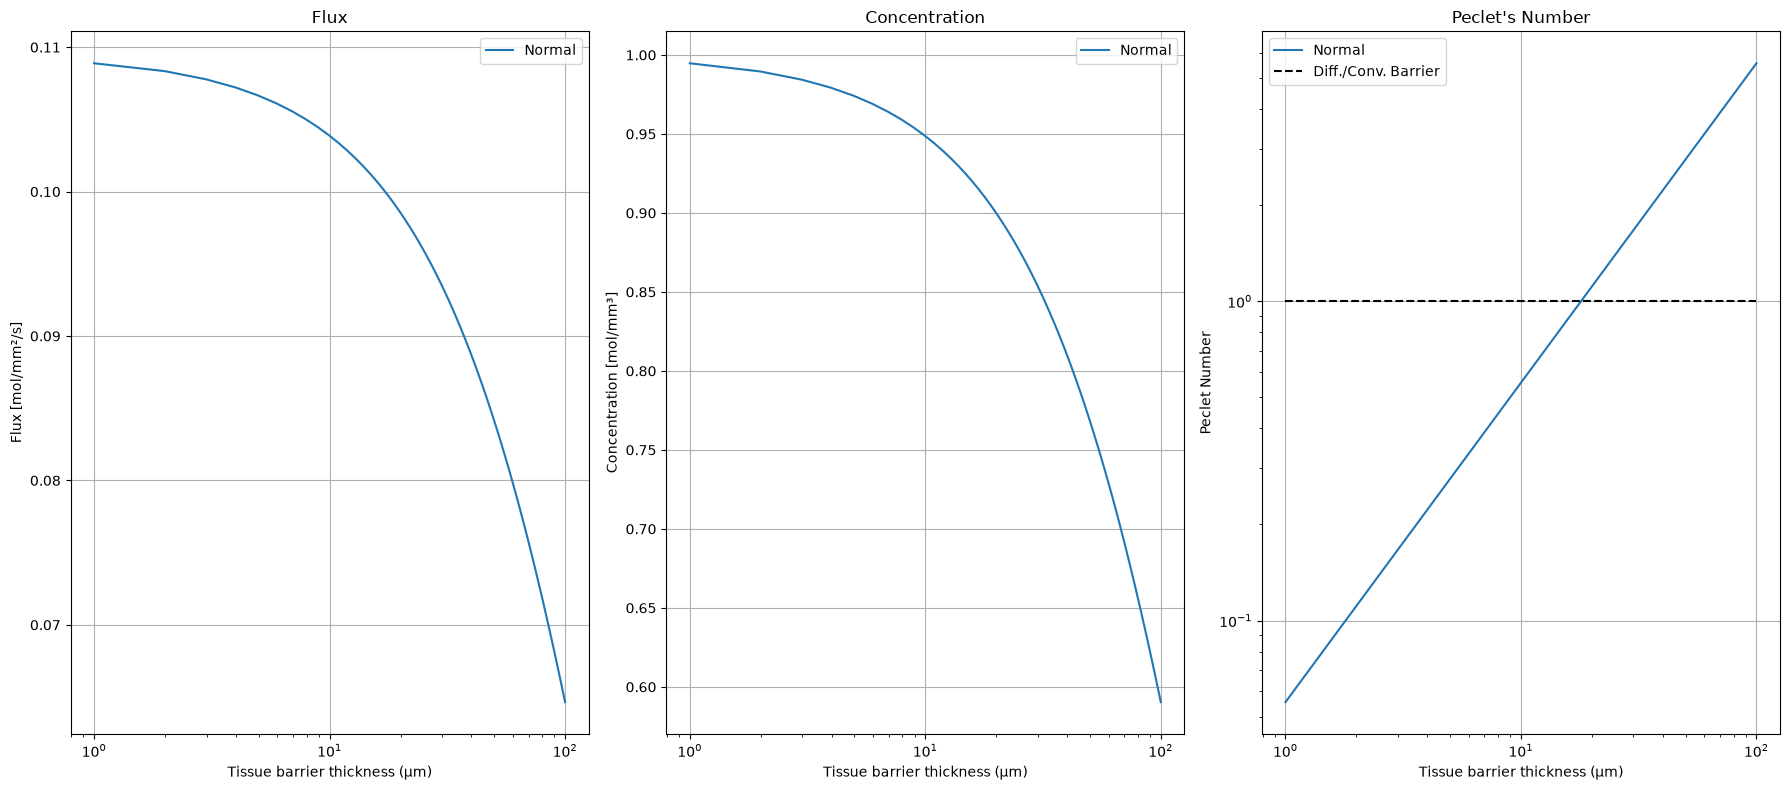

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes
from files.fluxmodel import concentration, flux, peclet  # Open the file to see the functions used below
L_axial = 1  # mm
L = 0.1  # mm
C0 = 1.0  # mol/mm^3
x = np.linspace(0.01 * L, L, 101)  # mm

conditions = {
    "Normal": {
        "v": 0.1,
        "D": 1.8e-3,
    },  # Normal Scenario, add new lines with different scenarios
}

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 8))
axs: list[matplotlib.axes.Axes]

for i, (label, params) in enumerate(conditions.items()):
    v = params["v"]
    D = params["D"]

    # Flux components
    C = concentration(x, L_axial, v, D, C0)
    Js = flux(x, C, v, D)
    Pe = peclet(x, D, v)

    # Plot fluxes
    axs[0].plot(x * 1e3, Js, label=label)

    # Plot concentration
    axs[1].plot(x * 1e3, C, label=label)

    # Plot peclet
    axs[2].plot(x * 1e3, Pe, label=label)

axs[0].set_title("Flux")
axs[0].set_xlabel("Tissue barrier thickness (μm)")
axs[0].set_ylabel("Flux [mol/mm²/s]")
axs[0].set_xscale("log")
axs[0].grid(True)
axs[0].legend()
axs[1].set_title("Concentration")
axs[1].set_xlabel("Tissue barrier thickness (μm)")
axs[1].set_ylabel("Concentration [mol/mm³]")
axs[1].set_xscale("log")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(
    x * 1e3,
    np.ones_like(x),
    label="Diff./Conv. Barrier",
    linestyle="--",
    color="k",
)
axs[2].set_title("Peclet's Number")
axs[2].set_xlabel("Tissue barrier thickness (μm)")
axs[2].set_ylabel("Peclet Number")
axs[2].set_xscale("log")
axs[2].set_yscale("log")
axs[2].grid(True)
axs[2].legend()
plt.tight_layout()
plt.show()


## Physiological Scenarios in the Convection-Diffusion Model

The model is used to simulate solute transport across tissue barriers includes two key parameters:

- **v**: velocity of fluid flow (e.g., interstitial or capillary flow)
- **D**: diffusion coefficient of the solute (e.g., oxygen)

These parameters determine how solute concentration changes across the tissue. We are now going to simulate two scenarios.
1. Valsalva Maneuver
2. Fibrosis

### Valsalva Maneuver

**Valsalva** is a forced exhalation against a closed airway, often used in clinical tests. It increases **intrathoracic pressure**, which can affect blood and interstitial flow.
In this task, you will simulate the **Valsalva Maneuver**, a physiological condition that increases intrathoracic pressure and fluid velocity.
- **Effect on $v$**: ↑ Increased velocity due to pressure-driven flow
- **Effect on $D$**: No direct change, but tissue compression may slightly alter diffusion



### Fibrosis
**Fibrosis** is the thickening and scarring of connective tissue, often due to chronic inflammation or disease.
- **Effect on  D**: ↓ Reduced diffusion due to dense extracellular matrix
- **Effect on  v**: May be unchanged or slightly reduced due to restricted flow


### Valsalva + Fibrosis
-  $v$ : ↑ Increased
-  $D$ : ↓ Decreased




## Exercise: Conditional effect on concentration

1. Extend the model to include three new conditions:

|| v | D |
|---|---|---|
|Normal| 0.1 | 1.8e-3 |
|Valsalva| 0.3 | 1.8e-3 |
|Fibrosis| 0.1 | 0.9e-3 |
|Valsalva + Fibrosis| 0.3 | 0.9e-3 |

*Note, in the code above, you can add scenarios, as elements in the `conditions` dictionary variable.*



2. **What happens to the solute transport in each case?**  
3. **What effect does this have on oxygen delivery to deeper tissue?**

### Answers